# VRM / VRMA cross-check

Applies the Velocity Ring Model (VRM) and its azimuthally-resolved extension
(VRMA) to this galaxy's velocity field, using the vendored reference
implementation in `vrm/VRM_VRMA.py`
(https://github.com/MatteoStraccamore/VRM_VRMA), and compares the result
against this project's own `s1(R)` measurement from `harmonic_fit.py`.

Method: Sylos Labini, Straccamore, De Marzo & Comerón, "Mapping
non-axisymmetric velocity fields of external galaxies", ApJ 988, 122 (2025),
doi:10.3847/1538-4357/adc71c. See `vrm/README.md` for how VRM/VRMA differs
methodologically from this project's own pipeline, and for a real upstream
gotcha (`phi0input` is accepted but never used) that `vrm/bridge.py` works
around explicitly.

**The short version of the difference:** `harmonic_fit.py` fixes the
rotation curve at Barolo's `VROT` and fits only `c0` and `s1` (=`v_r`). VRM
fits `v_t` *and* `v_r` together, per ring, with nothing held fixed but the
global geometry -- and its rings are equal-width bins in *rescaled* radius
over the full detected extent, not the Barolo tilted-ring edges this
project's other notebook uses. VRM also has **no built-in error
quantification** -- every number below is a point estimate, unlike the
bootstrap + PA/VSYS-scan error budget in `harmonic_pipeline.ipynb`.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.table import Table

import harmonic_fit as hf
from harmonic_plots import custom_rcparams
from vrm.bridge import run_vrm, cell_field_to_full_frame

mpl.rcParams.update(custom_rcparams)
project_dir = Path.cwd()

## Geometry and data-quality cut

Reuses this project's own ringlog, maps, and data-quality mask
(`sigma_artifact_floor_kms`) rather than re-deriving them -- see
`CLAUDE.md` Section 5.3 for why the near-zero-`mom2` cut exists. `P.A.` and
`INC` are identical across all four rings in this ringlog (no warp), so one
global geometry is used for VRM, matching the tilted-ring model's own
assumption in the inner disk.

In [2]:
ringlog = hf.read_ringlog(project_dir / "stage_1_opt_parameters.txt")
mapset = hf.load_maps(project_dir / "maps")
cdelt1_sign = -1 if mapset.cdelt1_deg < 0 else (1 if mapset.cdelt1_deg > 0 else 0)

row0 = ringlog[0]
xc, yc = float(row0["XPOS(pix)"]), float(row0["YPOS(pix)"])
pa_deg, inc_deg = float(row0["P.A.(deg)"]), float(row0["INC(deg)"])
vsys_barolo = float(row0["VSYS(km/s)"])
sigma_artifact_floor_kms = 0.5  # same cut as harmonic_fit.Config's default

print(f"PA = {pa_deg} deg, INC = {inc_deg} deg, Barolo VSYS = {vsys_barolo} km/s")

PA = 53.445 deg, INC = 49.345 deg, Barolo VSYS = 4677.0 km/s


## VRM: one (v_t, v_r) per ring

`number_rings=4` to sit alongside this project's own 4-ring result -- but
note the x-axis below is **not** guaranteed to line up with the Barolo ring
edges, since VRM bins by rescaled radius over the full extent of the good
pixels, whatever that extent turns out to be.

In [3]:
result_vrm = run_vrm(mapset, xc, yc, pa_deg, inc_deg, cdelt1_sign, sigma_artifact_floor_kms,
                      number_rings=4, number_arch=1)

print(f"VRM-fit VSYS = {result_vrm['vsys_fit']:.2f} km/s  "
      f"(Barolo ringlog VSYS = {vsys_barolo:.2f} km/s, "
      f"difference = {result_vrm['vsys_fit'] - vsys_barolo:+.2f} km/s)")
print(f"{result_vrm['n_good_pixels']} good pixels used")

result_vrm["table"]

4682.719042871236
VRM-fit VSYS = 4682.72 km/s  (Barolo ringlog VSYS = 4677.00 km/s, difference = +5.72 km/s)
440 good pixels used


ring_index,arc_index,r_arcsec_mean,theta_mean,n_points,v_t,v_r
int64,int64,float64,float64,int64,float64,float64
0,0,41.37659501309917,2.291968272800253,54,277.01744703494353,-23.200620695388277
1,0,55.73531466018569,3.1772377492869177,213,303.13178919390134,-50.2898517123972
2,0,69.74292685004171,2.9303499221307687,162,313.44028846557046,-44.29587354168329
3,0,87.35965837942868,1.3146971977754194,10,439.10937835027784,-101.52060063617006


## v_t(R) vs. Barolo's VROT, and v_r(R) vs. this project's s1(R)

Marker size scales with `sqrt(n_points)` in each VRM bin -- a small marker
is a bin fit from very few pixels and should not be trusted. The outermost
VRM ring in particular can extend past where Barolo's rings (and this
project's own analysis) stop, into much sparser territory.

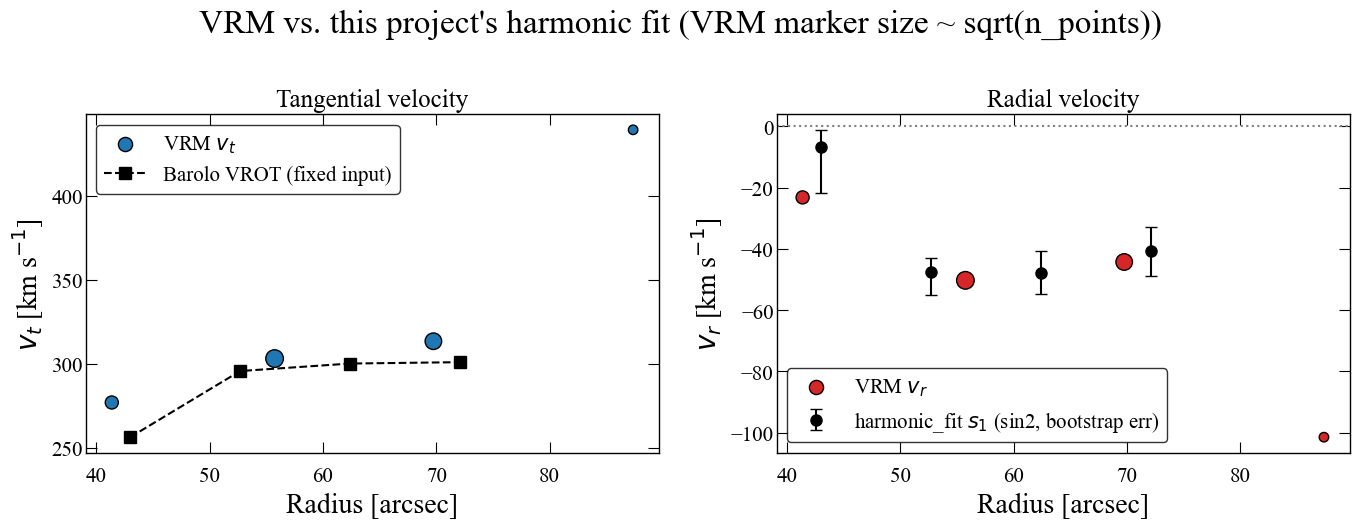

In [4]:
harm_table = Table.read(project_dir / "results" / "ring_results.ecsv", format="ascii.ecsv")
primary_weighting = harm_table.meta["primary_weighting"]
harm_both = harm_table[(harm_table["side"] == "both") & (harm_table["weighting"] == primary_weighting)]
harm_both.sort("ring_index")
r_arcsec_ours = (harm_both["r_in_arcsec"] + harm_both["r_out_arcsec"]) / 2.0

t = result_vrm["table"]
sizes = 15 + 10 * np.sqrt(t["n_points"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.scatter(t["r_arcsec_mean"], t["v_t"], s=sizes, c="tab:blue", edgecolor="black", label="VRM $v_t$", zorder=3)
ax1.plot(r_arcsec_ours, harm_both["vrot_kms"], "s--", color="black", label="Barolo VROT (fixed input)")
ax1.set_xlabel("Radius [arcsec]")
ax1.set_ylabel(r"$v_t$ [km s$^{-1}$]")
ax1.legend()
ax1.set_title("Tangential velocity")

ax2.scatter(t["r_arcsec_mean"], t["v_r"], s=sizes, c="tab:red", edgecolor="black", label="VRM $v_r$", zorder=3)
ax2.errorbar(r_arcsec_ours, harm_both["s1"],
             yerr=[harm_both["s1"] - harm_both["s1_boot_lo"], harm_both["s1_boot_hi"] - harm_both["s1"]],
             fmt="o", color="black", capsize=4, label=f"harmonic_fit $s_1$ ({primary_weighting}, bootstrap err)", zorder=4)
ax2.axhline(0, color="gray", linestyle=":")
ax2.set_xlabel("Radius [arcsec]")
ax2.set_ylabel(r"$v_r$ [km s$^{-1}$]")
ax2.legend()
ax2.set_title("Radial velocity")

fig.suptitle("VRM vs. this project's harmonic fit (VRM marker size ~ sqrt(n_points))")
fig.tight_layout()
None

## VRMA: azimuthally-resolved v_r(R, theta)

Splitting each ring into arcs trades points-per-bin for angular resolution.
Given how patchy this data's azimuthal coverage already is at the per-ring
level (see `fig_coverage` in `harmonic_pipeline.ipynb`), most bins at even
modest resolution end up under-constrained -- shown explicitly via
`n_points` (printed below) rather than smoothed over. Pixels in a bin with
fewer than 3 points (an under- or exactly-determined 2-parameter fit) are
left blank rather than colored by an unreliable estimate.

In [5]:
result_vrma = run_vrm(mapset, xc, yc, pa_deg, inc_deg, cdelt1_sign, sigma_artifact_floor_kms,
                       number_rings=4, number_arch=4)
t2 = result_vrma["table"]

n_total = len(t2)
n_unreliable = int(np.sum(t2["n_points"] < 3))
print(f"{n_unreliable} / {n_total} (ring, arc) bins have fewer than 3 points")

t2["ring_index", "arc_index", "r_arcsec_mean", "n_points", "v_t", "v_r"]

4682.719042871236
2 / 16 (ring, arc) bins have fewer than 3 points


ring_index,arc_index,r_arcsec_mean,n_points,v_t,v_r
int64,int64,float64,int64,float64,float64
0,0,39.726904025166235,30,248.01871728727383,-8.996044106340763
0,1,42.80494729287467,7,297.2442337765011,9.736868891213135
0,2,43.635953695230505,9,274.0289650359281,-3.0484133537525793
0,3,43.77134945564626,8,268.8154731327477,-114.88372253888508
1,0,55.18578103935578,62,275.13224289207415,-23.675468396797363
1,1,56.331577963325074,37,313.32979762976936,-37.60418694091628
1,2,55.69822673838983,58,309.36336419181464,-46.44105533275378
1,3,55.98817969124745,56,280.63656457621414,-85.65209762366219
2,0,71.31893835734759,66,289.115370143065,-23.61781525270338


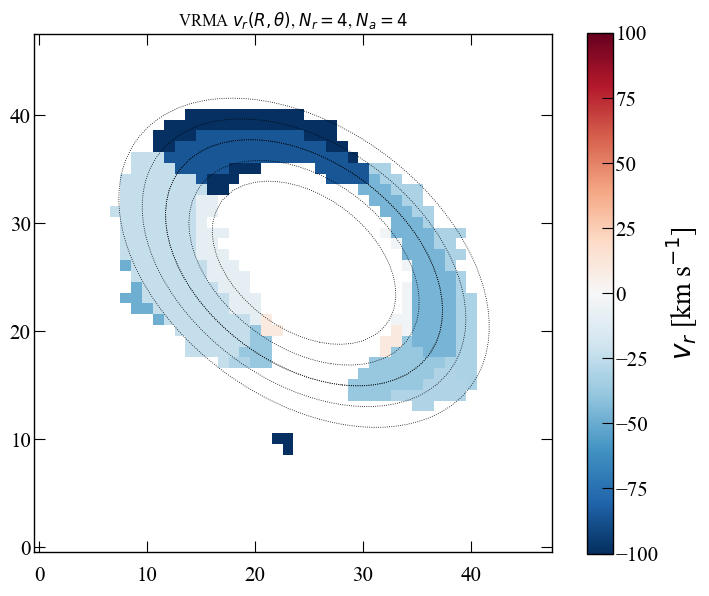

In [6]:
# Same map convention as harmonic_plots.py (fig_theta_map, fig_residual_maps,
# etc.): a full-frame array in the original pixel grid, NaN outside good
# pixels, shown with imshow -- not a scatter in some other coordinate
# system. Ring edge contours use this project's own Barolo ring boundaries
# as a familiar visual anchor, even though VRM's own rings (rescaled radius)
# don't line up with them exactly.
_R_arcsec_grid = hf.make_geometry(mapset.shape, xc, yc, pa_deg, inc_deg, cdelt1_sign)[0] * mapset.pixscale_arcsec
_ring_edges_arcsec = sorted(set(ringlog["r_in_arcsec"]).union(ringlog["r_out_arcsec"]))


def _map_panel(ax, result, field, cmap, vlim, title, cbar_label, min_points=3):
    t = result["table"]
    full = cell_field_to_full_frame(mapset.shape, result["mask"], result["cell_index"],
                                     np.asarray(t[field], dtype=float),
                                     n_points_per_cell=np.asarray(t["n_points"]), min_points=min_points)
    im = ax.imshow(full, origin="lower", cmap=cmap, vmin=vlim[0], vmax=vlim[1])
    ax.contour(_R_arcsec_grid, levels=_ring_edges_arcsec, colors="black", linewidths=0.6, linestyles=":")
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.06, label=cbar_label)
    return im


fig, ax = plt.subplots(figsize=(7.5, 7.5))
_map_panel(ax, result_vrma, "v_r", "RdBu_r", (-100, 100),
           "VRMA $v_r(R,\\theta)$, $N_r=4$, $N_a=4$", r"$v_r$ [km s$^{-1}$]")
fig.tight_layout()
None

## How the VRM paper breaks the v_rad-PA (warp) degeneracy, vs. this project's approach

Both this project and arXiv:2503.22306 are chasing the same worry -- that an
apparent radial-motion signal could actually be an artifact of getting the
disc's geometry slightly wrong -- but they attack it from different
directions, worth being explicit about before reproducing Figure 8 below.

**This project's approach (`harmonic_fit.py`, `harmonic_pipeline.ipynb`) is
analytic and perturbative, for a single constant PA offset.** Holding
`VROT` fixed at Barolo's value and fitting only `c0, s1`, a PA error `dPA`
contributes a `sin(theta)` residual -- the same harmonic as `s1` itself.
`CLAUDE.md` Section 5.6 derives the exact (inclination-corrected) leakage
slope `K(scheme)` in closed form by differentiating `make_geometry`, so
`s1_leak = VROT * K(scheme) * dPA[rad]` is known analytically, not just
simulated. `fig_pa_degeneracy` and `fig_s1_vs_pa` then scan `dPA` as a
single global number (appropriate here, since this ringlog's `P.A.` and
`INC` are constant across all four rings -- there is no warp to speak of)
and ask: does a plausible constant PA error alone reproduce the observed
`s1`? This needs no synthetic data and works fine on this dataset's ~440
pixels, because it's a closed-form sensitivity calculation, not a
statistical comparison between two noisy reconstructions.

**The VRM paper's approach (Sect. 3 of arXiv:2503.22306) is numerical and
built for a general, radially-varying warp.** It fits `v_t` *and* `v_r`
together with nothing held fixed but the (constant) global geometry, so it
has no equivalent of holding `VROT` fixed and no closed-form leakage
formula. Instead: run the TRM (allowing `i(R)`, `P.A.(R)` to vary per ring)
to get a candidate warp geometry; build a synthetic LOS velocity map from
*that* geometry assuming pure circular rotation (`v_r=0`); run the same
flat-disc-assuming VRMA on both the real data and the synthetic map; compare
the resulting `r_vtvr(R,theta)` rank-correlation maps. Their finding is that
a genuine warp, mis-analyzed by a method that assumes a flat disc, imprints
a specific `sin(2*theta)` dipole correlation shared between the `v_t` and
`v_r` artifacts -- so if the real galaxy's correlation map matches the toy
model's (Spearman `C > 0.2`, their Table 1 threshold), the signal is at
least partly a warp; if it doesn't, that is evidence for a genuine
intrinsic (non-warp) perturbation.

**Where they meet.** Our `K(scheme)` is, in effect, the linearized special
case of their general test, restricted to the one warp mode this galaxy's
own ringlog actually allows (a constant PA/INC error, not a radially-varying
one -- consistent with `P.A.`, `INC` being flat across rings in this
ringlog). The Figure 8 reproduction below reuses their machinery, but
because there is no warp in this ringlog to begin with, the toy model here
is deliberately a **no-warp control** (Barolo's own pure-circular-rotation
model map) rather than a warp hypothesis -- so `C_warp` below is asking
"does the VRMA method itself imprint a spurious dipole correlation on data
this sparse, even with no real warp present", a different (also useful)
question from `harmonic_fit.py`'s "could a constant PA error explain the
detected `s1`". Agreement between the two projects' PA/geometry
sensitivity checks (neither finds a single simple geometry error that
explains away the signal) is two independent methods pointing the same way.

## Figure 8 reproduction: v_t, v_r, and their rank-correlation map, vs. a toy null model

Reproduces Figure 8 of Sylos Labini, De Marzo & Straccamore (2025), ApJ 988,
122, doi:10.3847/1538-4357/adc71c -- their warp/radial-flow diagnostic, built
from: the VRMA-reconstructed `v_t(R,theta)` and `v_r(R,theta)` for this
galaxy; the same for a toy/null model; the rank (Spearman) correlation
coefficient map between `v_t` and `v_r`, for both; the observed velocity
dispersion `sigma(R,theta)`; and its rank-correlation with `v_t` and `v_r`.
A tenth panel (not in the paper) adds the LOS residual, at your request.

**Two interpretive choices, documented in `vrm/README.md`:**

1. **The toy model is Barolo's own model map.** The paper's toy model is
   pure circular rotation built from the TRM's `i(R)`, `phi0(R)`, `v_c(R)`,
   with `v_r=0`. This ringlog has **no warp** (`P.A.`, `INC` constant across
   all four rings) and `VRAD` fixed at 0 -- which means `_local_1mom.fits`
   (Barolo's own model map, already loaded as `mapset.model_mom1`) *is*
   exactly that toy model, generated independently by BBarolo. Rather than
   resynthesize a duplicate, this reuses it directly: same mask, same
   geometry, run through the identical VRMA pipeline.
2. **The correlation "map."** The paper's Eq. 2 sums a per-cell term (Eq. 3)
   over *all* cells to give a single scalar; the text and the Figure 8
   caption both call the plotted quantity a spatial "map" `r_fg(R,theta)`
   without giving a separate formula for it. The map used below is that
   per-cell term itself (Spearman version: standardized ranks, not raw
   values) -- the only quantity in the paper's own equations that varies by
   position *and* whose sum, divided by `N_cells - 1`, reproduces Eq. 2's
   scalar exactly.

**Resolution:** the paper's fiducial grid is `Nr=50, Na=32` on THINGS data
(thousands of pixels per galaxy). This dataset has ~440 good pixels *total*
-- `Nr=4, Na=4` (matching the VRMA demo above) is already only ~20-30
points/cell in the best rings. Cells with fewer than 3 points (the minimum
for a determined 2-parameter fit) are excluded from every quantity below,
not just greyed out, since `VRM._matrix()` returns exactly `0.0` for an
empty cell -- a real number that would otherwise silently corrupt the
correlation maps and the residual.

In [7]:
from vrm.bridge import run_figure8_analysis

fig8 = run_figure8_analysis(mapset, xc, yc, pa_deg, inc_deg, cdelt1_sign, sigma_artifact_floor_kms,
                             number_rings=4, number_arch=4)

n_usable = int(np.sum(np.asarray(fig8["table"]["n_points"]) >= 3))
n_cells = len(fig8["table"])

print(f"VRM-fit VSYS: data = {fig8['vsys_fit']:.2f} km/s, toy model = {fig8['vsys_fit_toy']:.2f} km/s "
      f"(Barolo ringlog VSYS = {vsys_barolo:.2f} km/s)")
print(f"{n_usable} / {n_cells} cells usable (>= 3 points)")
print(f"Overall Spearman C(r_vtvr data, r_vtvr toy) = {fig8['C_warp']:.2f}  "
      f"(paper's threshold: |C| > 0.2 suggests a warp signature -- but with only "
      f"{n_usable} usable cells here, versus the paper's Nr=50 x Na=32 = 1600, "
      f"treat this as exploratory, not a firm detection)")
print(f"C(sigma, v_t) = {fig8['C_sigma_vt']:.2f}, C(sigma, v_r) = {fig8['C_sigma_vr']:.2f}")

fig8["table"]["ring_index", "arc_index", "n_points", "v_t", "v_r", "v_t_tm", "v_r_tm", "sigma_mean", "residual"]

4682.719042871236
4677.106362149485
VRM-fit VSYS: data = 4682.72 km/s, toy model = 4677.11 km/s (Barolo ringlog VSYS = 4677.00 km/s)
14 / 16 cells usable (>= 3 points)
Overall Spearman C(r_vtvr data, r_vtvr toy) = -0.23  (paper's threshold: |C| > 0.2 suggests a warp signature -- but with only 14 usable cells here, versus the paper's Nr=50 x Na=32 = 1600, treat this as exploratory, not a firm detection)
C(sigma, v_t) = -0.19, C(sigma, v_r) = 0.45


ring_index,arc_index,n_points,v_t,v_r,v_t_tm,v_r_tm,sigma_mean,residual
int64,int64,int64,float64,float64,float64,float64,float64,float64
0,0,30,248.01871728727383,-8.996044106340763,267.5676303079879,0.034055396533570814,18.984814755121867,0.2795245960253851
0,1,7,297.2442337765011,9.736868891213135,271.569903618828,4.458474070250444,13.306581769670759,0.07588803287113219
0,2,9,274.0289650359281,-3.0484133537525793,271.14281150503746,3.538334592147301,17.47458291053772,-0.5446029415296734
0,3,8,268.8154731327477,-114.88372253888508,271.8410647880105,-0.8631711962730719,12.64855045080185,0.07863612327469127
1,0,62,275.13224289207415,-23.675468396797363,287.9153197359837,-0.17287288755603214,19.416180518365675,0.20212730051618213
1,1,37,313.32979762976936,-37.60418694091628,287.51469646605284,-1.9222029065540336,15.568596221305228,1.0608058342574156
1,2,58,309.36336419181464,-46.44105533275378,288.1823380902194,1.1972938282686716,20.217628446118585,0.5540971749204769
1,3,56,280.63656457621414,-85.65209762366219,287.38626163191213,-2.6680908968435233,16.031562430518015,-0.4145782730521757
2,0,66,289.115370143065,-23.61781525270338,300.3816259247882,-0.5199979774312249,15.713087977785053,0.1873134450345953


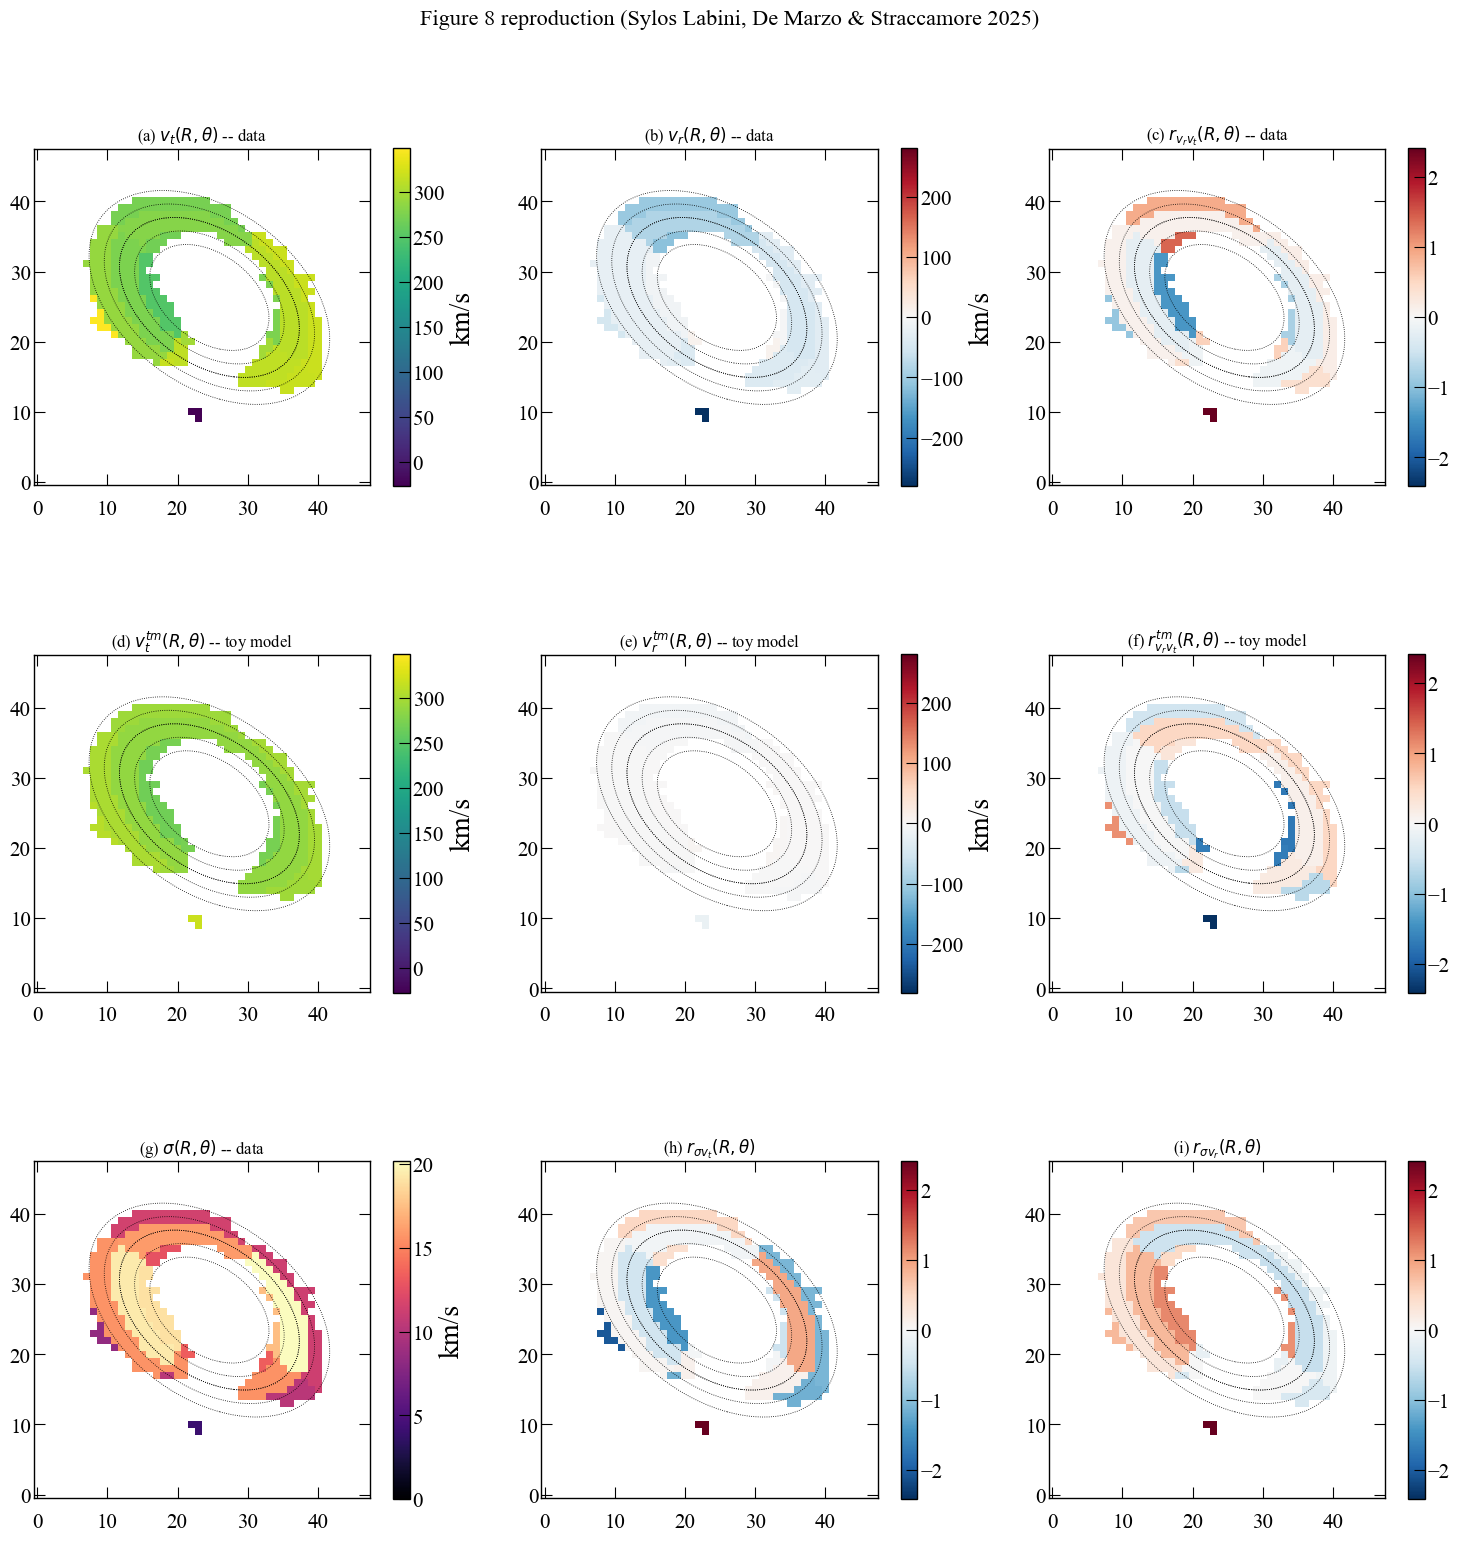

In [8]:
t = fig8["table"]
v_t_all = np.concatenate([np.asarray(t["v_t"]), np.asarray(t["v_t_tm"])])
v_t_lim = (np.nanmin(v_t_all), np.nanmax(v_t_all))
v_r_lim_abs = np.nanmax(np.abs(np.concatenate([np.asarray(t["v_r"]), np.asarray(t["v_r_tm"])])))
r_lim_abs = np.nanmax(np.abs(np.concatenate([
    np.asarray(t["r_vtvr"]), np.asarray(t["r_vtvr_tm"]), np.asarray(t["r_sigma_vt"]), np.asarray(t["r_sigma_vr"]),
])))
sigma_lim = (0, np.nanmax(np.asarray(t["sigma_mean"])))

fig, axes = plt.subplots(3, 3, figsize=(15, 16))

_map_panel(axes[0, 0], fig8, "v_t", "viridis", v_t_lim, "(a) $v_t(R,\\theta)$ -- data", "km/s")
_map_panel(axes[0, 1], fig8, "v_r", "RdBu_r", (-v_r_lim_abs, v_r_lim_abs), "(b) $v_r(R,\\theta)$ -- data", "km/s")
_map_panel(axes[0, 2], fig8, "r_vtvr", "RdBu_r", (-r_lim_abs, r_lim_abs), "(c) $r_{v_rv_t}(R,\\theta)$ -- data", "")

_map_panel(axes[1, 0], fig8, "v_t_tm", "viridis", v_t_lim, "(d) $v_t^{tm}(R,\\theta)$ -- toy model", "km/s")
_map_panel(axes[1, 1], fig8, "v_r_tm", "RdBu_r", (-v_r_lim_abs, v_r_lim_abs), "(e) $v_r^{tm}(R,\\theta)$ -- toy model", "km/s")
_map_panel(axes[1, 2], fig8, "r_vtvr_tm", "RdBu_r", (-r_lim_abs, r_lim_abs), "(f) $r^{tm}_{v_rv_t}(R,\\theta)$ -- toy model", "")

_map_panel(axes[2, 0], fig8, "sigma_mean", "magma", sigma_lim, "(g) $\\sigma(R,\\theta)$ -- data", "km/s")
_map_panel(axes[2, 1], fig8, "r_sigma_vt", "RdBu_r", (-r_lim_abs, r_lim_abs), "(h) $r_{\\sigma v_t}(R,\\theta)$", "")
_map_panel(axes[2, 2], fig8, "r_sigma_vr", "RdBu_r", (-r_lim_abs, r_lim_abs), "(i) $r_{\\sigma v_r}(R,\\theta)$", "")

fig.suptitle("Figure 8 reproduction (Sylos Labini, De Marzo & Straccamore 2025)", fontsize=16, y=0.995)
fig.tight_layout()
None

### Added panel: LOS residual (not in the paper)

Observed `v_los` minus the VRMA-reconstructed `v_los` (each cell's own
fitted `v_t`, `v_r` run back through Eq. 1), binned the same way as every
panel above -- the same diagnostic role as `fig_residual_maps`'s post-fit
panel elsewhere in this project, here for the VRM fit rather than the
harmonic fit.

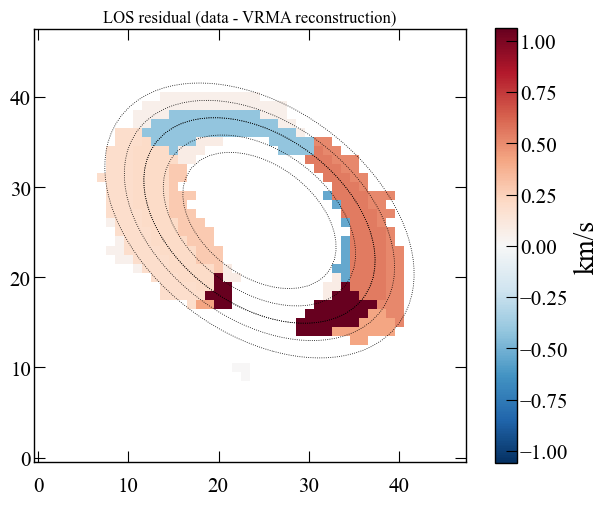

In [9]:
resid_lim = np.nanmax(np.abs(np.asarray(t["residual"])))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
_map_panel(ax, fig8, "residual", "RdBu_r", (-resid_lim, resid_lim), "LOS residual (data - VRMA reconstruction)", "km/s")
fig.tight_layout()
None

## Summary

- VRM's independently-fit systemic velocity and this project's Barolo-ringlog
  `VSYS` should agree closely if the two methods' geometry assumptions are
  compatible; a large discrepancy is itself informative.
- The `v_t(R)` comparison is a sanity check on VRM's geometry, not a new
  result -- Barolo's `VROT` was held fixed as an *input* to `harmonic_fit.py`,
  so close agreement there is closer to "necessary" than "confirmatory";
  VRM fits it independently, and its rings extend past this project's own
  fitted radius range, into territory Barolo's tilted-ring model was never
  asked to cover either.
- The `v_r(R)` comparison is the actual cross-check: VRM makes no assumption
  about `VROT`, uses a different radial binning, and has entirely different
  systematics (no PA-degeneracy handling, no bootstrap) from this project's
  `s1(R)`. Agreement between the two, within VRM's un-quantified point-to-point
  scatter, is independent support for the radial-motion detection; disagreement
  points at systematics specific to one method rather than the other.
- Take every VRM/VRMA point estimate with its `n_points` in hand -- the
  method returns a number even from an empty or near-empty bin (see
  `vrm/README.md`), and this dataset's coverage is patchy enough that this
  happens often once arcs are introduced.
- The Figure 8 reproduction's `C_warp` is a much noisier version of the same
  idea as Table 1 in Sylos Labini, De Marzo & Straccamore (2025): a large
  `|C|` between the data's and the toy model's `r_vtvr(R,theta)` maps points
  at a warp rather than intrinsic radial motion. With only a handful of
  usable cells at this dataset's resolution, read it as a rough, exploratory
  signal, not a resolved warp/no-warp verdict.